In [1]:
!pip install obspy matplotlib numpy 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import obspy 
from obspy import read, read_inventory, UTCDateTime
from obspy.clients.fdsn import Client
import numpy as np

#Configurar o SCEDEC 

In [3]:
pasta_dados = r'C:\Users\vish8\OneDrive\Documentos\SeriesTemporaisSismicas\data\scedc-pds\event_waveforms\2016\2016_001\37509256.ms'
print(pasta_dados[:10])

C:\Users\v


In [4]:
st = read(pasta_dados)
print(st)

554 Trace(s) in Stream:

AZ.BZN..BHE | 2016-01-01T00:42:05.594500Z - 2016-01-01T00:43:08.569500Z | 40.0 Hz, 2520 samples
...
(552 other traces)
...
WR.PEC..HNZ | 2016-01-01T00:42:14.375000Z - 2016-01-01T00:43:16.370000Z | 200.0 Hz, 12400 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]


AZ.BZN..BHZ | 2016-01-01T00:42:03.594500Z - 2016-01-01T00:43:09.569500Z | 40.0 Hz, 2640 samples
trace encontrado
         network: AZ
         station: BZN
        location: 
         channel: BHZ
       starttime: 2016-01-01T00:42:03.594500Z
         endtime: 2016-01-01T00:43:09.569500Z
   sampling_rate: 40.0
           delta: 0.025
            npts: 2640
           calib: 1.0
         _format: MSEED
           mseed: AttribDict({'dataquality': 'D', 'number_of_records': 22, 'encoding': 'STEIM2', 'byteorder': '>', 'record_length': 512, 'filesize': 6772224})


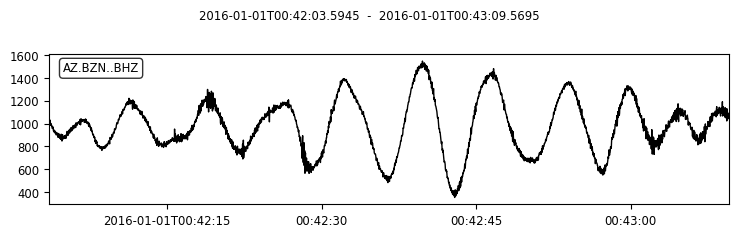

In [5]:
##Escolhendo um trace
tr = None
for trace in st:
    if trace.stats.channel.endswith('BHZ'):
        tr = trace
        break
if tr is not None:
    print(tr)
    print('trace encontrado')
    print(tr.stats)
    tr.plot()
else:
    print('Nenhum trace com canal BHZ encontrado')

O grafico acima é um sismograma de um canal vertical BHZ da estação BZN (rede AZ): 

 - Eixo X(horizontal) : Calcula o tempo de 42:03 até 43:09
 - Eixo Y : amplitude em counts (unidades analógio-digitais). Varia cerca de 400-1600 counts.
 - O que vemos ? Um sinal relativamente plano (ruido defundo) até aprox 42:30, onde começa uma oscilação de maior amplitude - provavelmente a chegada das ondas sismicas de um terremoto. O pico principal ocorre por valora de 42:40 - 42:45

-> Sendo um evento sismico tipico registrado por uma estação distante de epicentro. O fato de termos um canal vertical (BHZ) é otimo, pois é o o mais usado para detecção

Rede AZ – rede sismográfica (pode ser temporária ou regional).

Estação BZN – código da estação.

Canal BHZ – banda larga (Broadband), componente vertical (Z).

Taxa de amostragem 40 Hz – 40 amostras por segundo → cada amostra representa 0,025 segundos.

2640 amostras → duração total = 2640 / 40 = 66 segundos (compatível com o intervalo no gráfico).

In [6]:
from obspy.clients.fdsn import Client
client = Client("SCEDC")
inv = client.get_stations(network = 'AZ',
                          station = 'BZN',
                          starttime= tr.stats.starttime,
                          endtime = tr.stats.endtime,
                          level = 'response')
inv.write('AZ.BZN.xml', format='STATIONXML')

In [7]:
inv = read_inventory('C:\\Users\\vish8\\OneDrive\\Documentos\\SeriesTemporaisSismicas\\data\\scedc-pds\\FDSNstationXML\\AZ\\AZ.BZN.xml')
print(inv)

Inventory created at 2026-03-02T14:02:32.000000Z
	Created by: SCEDC WEB SERVICE: fdsnws-station | version: 1.1
		    http://service.scedc.caltech.edu/fdsnws/station/1/query?net=AZ&sta=...
	Sending institution: SCEDC (SCEDC)
	Contains:
		Networks (1):
			AZ
		Stations (1):
			AZ.BZN (Buzz Northerns Place, Anza, CA, USA)
		Channels (27):
			AZ.BZN..BHZ, AZ.BZN..BHN, AZ.BZN..BHE, AZ.BZN..HHZ, AZ.BZN..HHN, 
			AZ.BZN..HHE, AZ.BZN..HNZ, AZ.BZN..HNN, AZ.BZN..HNE, AZ.BZN..LCE, 
			AZ.BZN..LCQ, AZ.BZN..LHZ, AZ.BZN..LHN, AZ.BZN..LHE, AZ.BZN..VCO, 
			AZ.BZN..VEA, AZ.BZN..VEC, AZ.BZN..VEP, AZ.BZN..VKI, AZ.BZN..VM0, 
			AZ.BZN..VM1, AZ.BZN..VM2, AZ.BZN..VM3, AZ.BZN..VM4, AZ.BZN..VM5, 
			AZ.BZN..VM6, AZ.BZN..VPB


In [8]:
#Preparando um prefiltro
tr_pre = tr.copy()
#Removendo tendencia linear e media 
#Tendencia linear: é uma linha reta que pode ser adicionada a um sinal devido a fatores como instrumentação, condições ambientais ou processos geológicos. A remoção da tendência linear ajuda a destacar as variações reais do sinal.
#Removendo a média: A média é o valor médio de um conjunto de dados. Remover a média ajuda a centralizar o sinal em torno de zero, facilitando a análise das variações.
tr_pre.detrend(type = 'linear')
tr_pre.detrend(type = 'demean')
#Aplicando um taper (suavizar as bordas) - 5% é um valor sguro
tr_pre.taper(max_percentage = 0.05, type = 'cosine')
print(tr_pre)

AZ.BZN..BHZ | 2016-01-01T00:42:03.594500Z - 2016-01-01T00:43:09.569500Z | 40.0 Hz, 2640 samples


Definindo um pre filtro

Baseado na taxa de amostragem (40 Hz) e no espectro de eventros regionais, use: 
- Frequencia de Nyquist : 20 Hz(metade de 40). O filtro deve zerar acima de 20 Hz para evitar aliasing.
- f3=18, f4=20 -> Garantem a uma transição suave até o corte
- f1= 0.5, f2= 1 : Eliminam o ruido de longo periodo (microsismos oceanicos) sem afetar a banda de interesse



In [9]:
pre_filt = (0.5, 1.0, 18.0, 20.0)

Remocao concluida


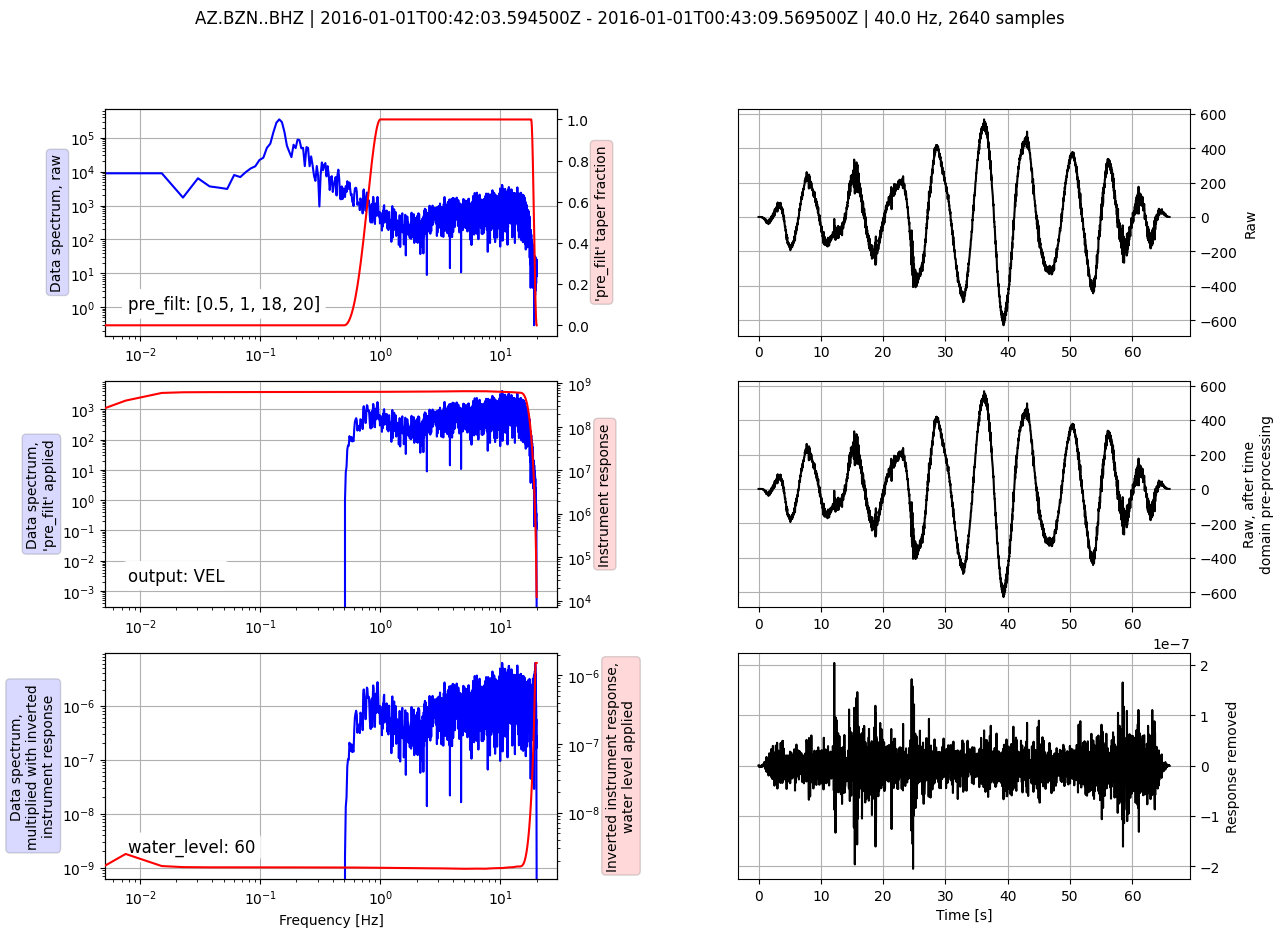

In [10]:
#Aplicando recomcao de resposta
tr_corr = tr_pre.copy()
tr_corr.remove_response(inventory = inv, #Inventario carregado (AZ.BZN.xml)
                        output = 'VEL', #Saida de velocidade (m/s)
                        pre_filt = pre_filt,
                        water_level = 60, #Valor padrao, evita amplificação estabiliza a resposta em frequências onde a resposta é fraca
                        plot = True)

print('Remocao concluida')

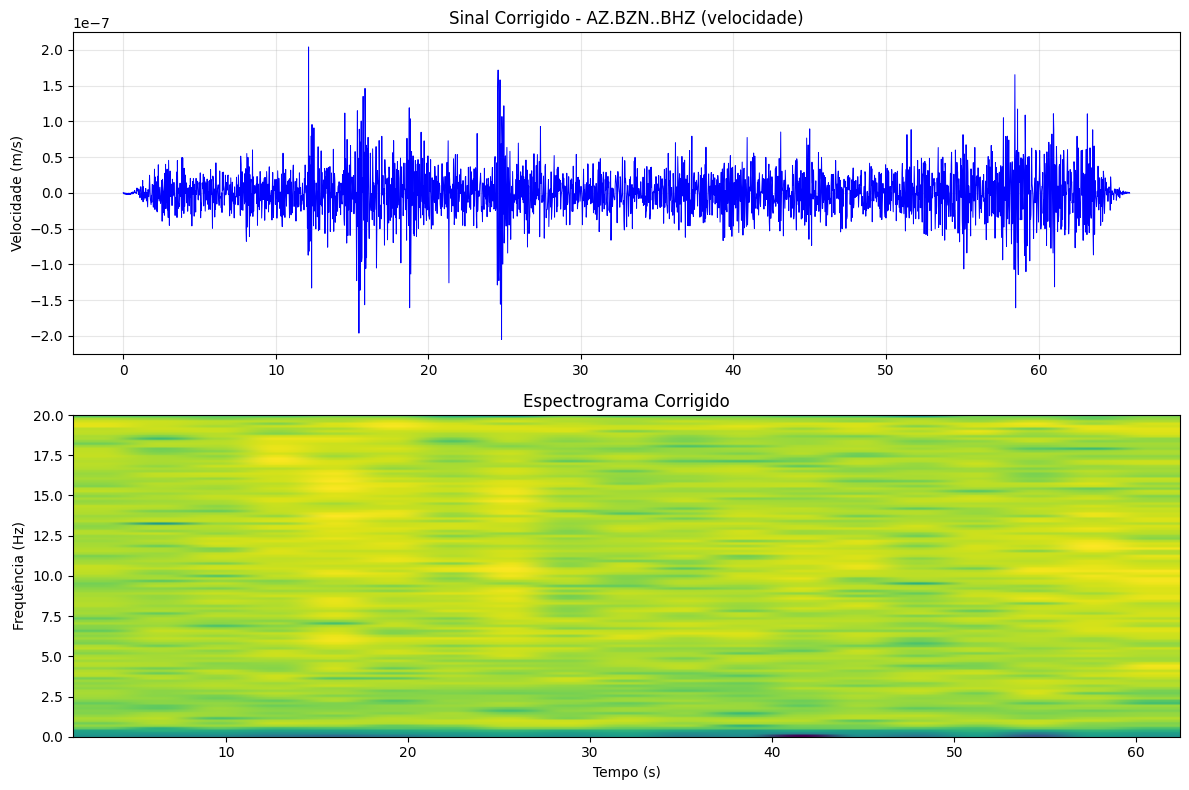

In [11]:
import matplotlib.pyplot as plt

# Supondo que tr_corr seja o trace após remove_response
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Sinal no tempo
ax1.plot(tr_corr.times(), tr_corr.data, 'b', linewidth=0.7)
ax1.set_ylabel('Velocidade (m/s)')
ax1.set_title('Sinal Corrigido - AZ.BZN..BHZ (velocidade)')
ax1.grid(True, alpha=0.3)

# Espectrograma (opcional, mas útil)
ax2.specgram(tr_corr.data, Fs=tr_corr.stats.sampling_rate, NFFT=256, noverlap=128)
ax2.set_ylabel('Frequência (Hz)')
ax2.set_xlabel('Tempo (s)')
ax2.set_title('Espectrograma Corrigido')

plt.tight_layout()
plt.show()

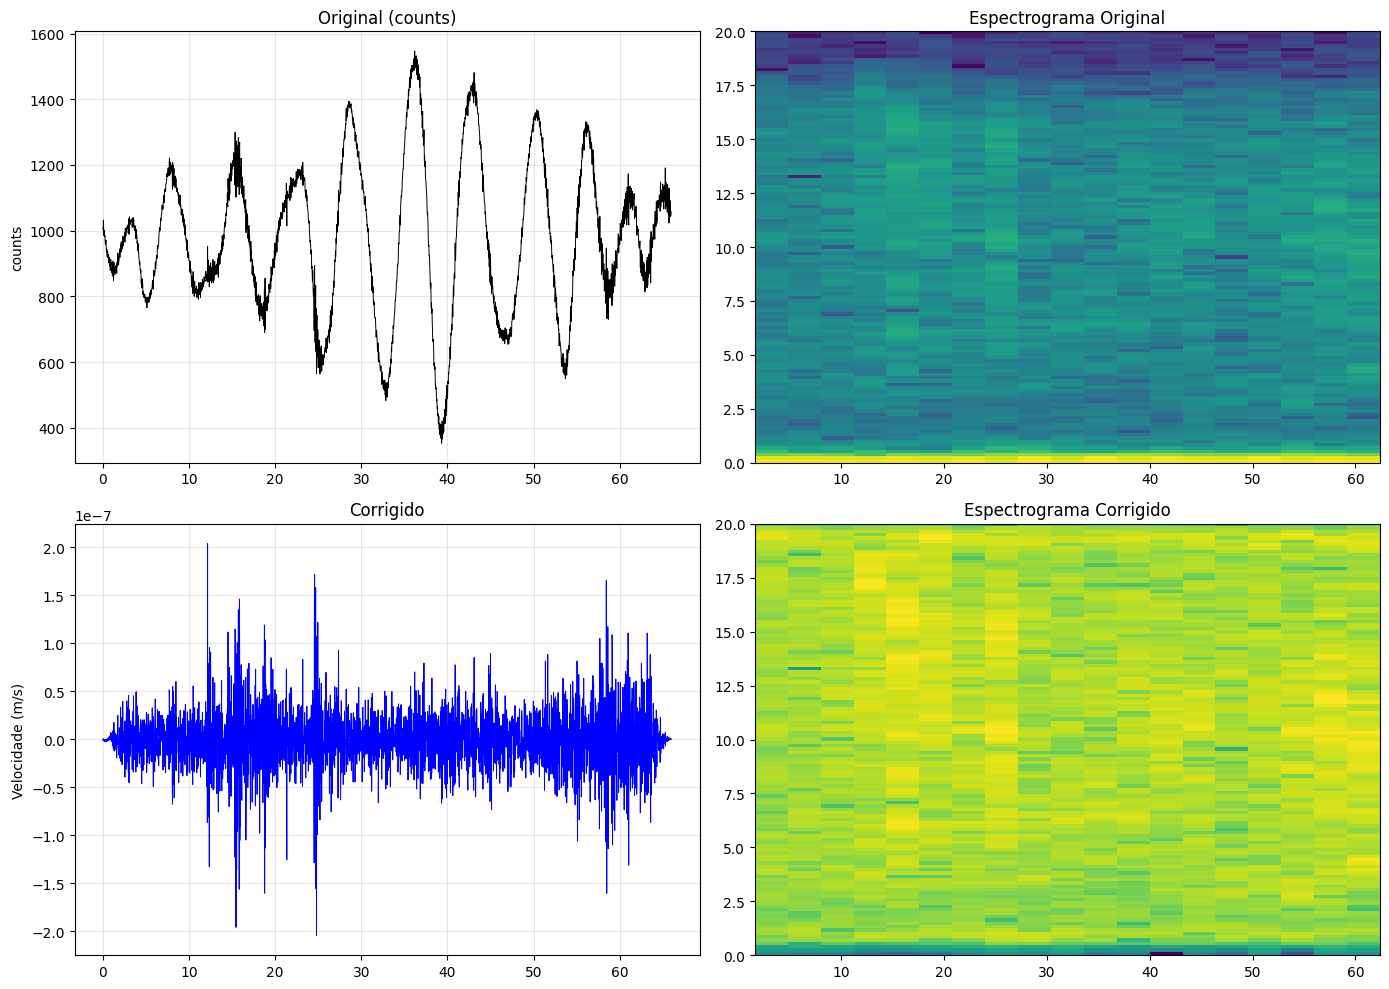

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original (counts)
axes[0,0].plot(tr.times(), tr.data, 'k', linewidth=0.7)
axes[0,0].set_ylabel('counts')
axes[0,0].set_title('Original (counts)')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].specgram(tr.data, Fs=tr.stats.sampling_rate, NFFT=256, noverlap=128)
axes[0,1].set_title('Espectrograma Original')

# Corrigido (m/s)
axes[1,0].plot(tr_corr.times(), tr_corr.data, 'b', linewidth=0.7)
axes[1,0].set_ylabel('Velocidade (m/s)')
axes[1,0].set_title('Corrigido')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].specgram(tr_corr.data, Fs=tr_corr.stats.sampling_rate, NFFT=256, noverlap=128)
axes[1,1].set_title('Espectrograma Corrigido')

plt.tight_layout()
plt.show()

Interpretação do sinal 
**SInais superiores :** 
Sinal original = Eixo X : Amplitude em counts; Eixo y = tempo
    Temos que observar o pico positivo por volta do centro do grafico( 00:42:30 - 00:42:45). É um terremeto típico: Chegada abrupta seguida de decaimento;
    - Escala esta em milhasres de coubts - isso é esperado paara dados crus
    - Pequenas oscilações antes e depois sao o ruido de fundo

**Interpretando espectograma :** 
-> Superior direito :
    Eixo X : Tempo (mesmo do sinal)

    Eixo Y : Frequencia em HZ. Pela tabela, pareque o eixo Y vai de 0 a cerca de 17.5Hz(devido a taxa de amostragem de 40 HZ, a frequencia maxima represntavel é de 20Hz, entao o espectograma mostra até ~17.5Hz)

    Cores : Indicam a intensidade(energia) em cada frequencia ao longo do tempo. Cores mais quentes, amarelo/vermelho indicam mais energia

    No que observar:
    - No momento do evento, há uma faixa vertiical de alta energia em todas as frequencia - isso é o terremoto

    - Antes e depois, as cores são mais frias (azul), indicando apenas um ruido

    - Possivel distorção instrumental : as vezes a resposta do instruimento pode fazer com que certas frequencias apreçam mais intensas do que realmente são. Neste espectograma, parece que as frequencias mais baixas ( < 5hz) tem energia mais forte, o que pode ser devido a resposta do instruimento ( amplificação natural em baixas frequencias)



**Inferiores **

Sianl corrigido
    -Eixo Y : Amplitude em m/s (agora em unidades fisicas). Pelos valores da tabela, a amplitude caiu drasticamente, os numeros na coluna 'corrigido' sao da ordem de 10e-10 a 10e-6 ? na verdade, a tabela mostra valores como 0.5, 0.0017, o que nao parece compativel com m/s. Provavelmente a tabela está mostrando outra coisa. Mas nog rafico, a escala do eixo y deve estar em valores muitos pequenos (10e-6 a 10e-3)

    -O que observar : A forma do evento deve ser preservada: Ainda vemos o pico principal
                       A amplitude agora é fisicamente significativa. Para terremotos pequenos, valores de 10e-6 m/s são comuns. para eventos maiores, pode chegar a 10e-3;
                       Compando ao original a forma é a mesma mas a escala mudou

Espectograma: Agora o espectograma mostra a distribuição de energia após a correção.

    O que observar : A energia ainda está concentrada no momento do evento, mas a distribuição pelas frequencias deve estar mais equilibrada.
                     Idealmente, a repsosta do instrumento foi removida, entao as frequencias que antes eram artificialmente amplificadas agora devem ter energia proporcional ao movimento real do solo
                     Se a correção for bem feita, o espectograma corrigido mostra um borrão mais unifrme nas frequencias, sem realces artificiais


### Como saber se a remoção foi bem sucedida

1. Escala da aplitude no dominio do tempo passou de milhares (counts) para valores pequenos 
2. Forma do evento permanece recognoscivel - nao foi distorcida
3. Espectograma corrigido nao apresenta faixas de frequencia excessivamente realçãdas, a energia está distribuida de forma mais natural
4. O grafico gerado por 'remove_response(plot = True)' indicou que a correção foi estável, sem picos espurios


### COnstrução da pipeline de pre-processamento
Leitura do arquivo e seleção do canal desejado (ex: vertical).

Remoção de tendência linear e média.

Aplicação de taper.

Remoção de resposta instrumental (conversão para velocidade).

Filtragem passa-banda (opcional, mas recomendada).

Normalização (z-score) para que todas as amostras tenham média 0 e desvio 1.

Retorno do dado processado (array numpy) e metadados relevantes.

In [1]:
from typing import Tuple 
import numpy as np
def preprocessar_waveform(caminho_wave : str, caminho_env : str, canal_alvo: str = 'BHZ', output: str = 'VEL', pre_filt: Tuple = (0.5, 1.0, 18.0, 20.0),
                       water_level : float = 60, normalizar : bool = True, plot: bool = False) -> Tuple[np.ndarray, dict]:
    """
    Pipeline para processar uma waveform, incluindo remoção de resposta.
    Parametros : 
    - caminho_wave : str, caminho para o arquivo da waveform (.ms)
    - caminho_inv : str, caminho para o arquivo de inventário (STATIONXML)
    - canal_alvo : str, codigo do canal desejado (ex: 'BHZ')
    - output : str, tipo de saida desejada ('VEL', 'DISP', 'ACC')
    - pre_filt : tuple, frequencias de corte para o prefiltro (f1,f2,f3,f4)
    - water_level : float, valor do water level para estabilização da resposta
    - normalizar : bool, se True, normaliza o sinal corrigido
    - plot : bool, se True, plota os espectrogramas antes e depois da correção

    Retorna: 
    - dados: numpy array 1D com sinal processado
    - stats : dicionario com metadados uteis (taxa, estação, etc)

    """
    #Carregando o stream e selecionando o canal alvo
    st = read(caminho_wave)
    tr = None 
    for trace in st:
        try:
            if trace.stats.channel.endswith(canal_alvo):
                tr = trace.copy()
                break
        except AttributeError:        
            raise ValueError(f'Nenhum trace com canal {canal_alvo} encontrado em {caminho_wave}')
        
    #Extrair metaddados importantes
    stats = {
        'network': tr.stats.network,
        'station': tr.stats.station,
        'channel': tr.stats.channel,
        'sampling_rate': tr.stats.sampling_rate,
        'starttime': tr.stats.starttime,
        'npts': tr.stats.npts
    }
    
    #Pre processamento basico
    tr.detrend(type = 'linear')
    tr.detrend(type = 'demean')
    tr.taper(max_percentage = 0.05, type = 'cosine')
    
    #Carregand o o inventário
    inv = read_inventory(caminho_env)
    #Removendo resposta
    tr.remove_response(inventory = inv, output = output, pre_filt = pre_filt, water_level = water_level)
    tr.filter('bandpass', freqmin=0.5, freqmax=15.0)   
    
    #Normalizar (z-score)
    dados = tr.data
    if normalizar:
        dados = (dados - np.mean(dados)) / np.std(dados)
    # 7. Plot opcional
    if plot:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
        ax1.plot(tr.times(), tr.data, 'b', lw=0.7)
        ax1.set_ylabel(output)
        ax1.set_title(f'Sinal processado - {tr.id}')
        ax1.grid(True, alpha=0.3)
        
        ax2.plot(tr.times(), dados, 'r', lw=0.7)
        ax2.set_ylabel('Normalizado')
        ax2.set_xlabel('Tempo (s)')
        ax2.set_title('Após normalização')
        ax2.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    return dados, stats       
        

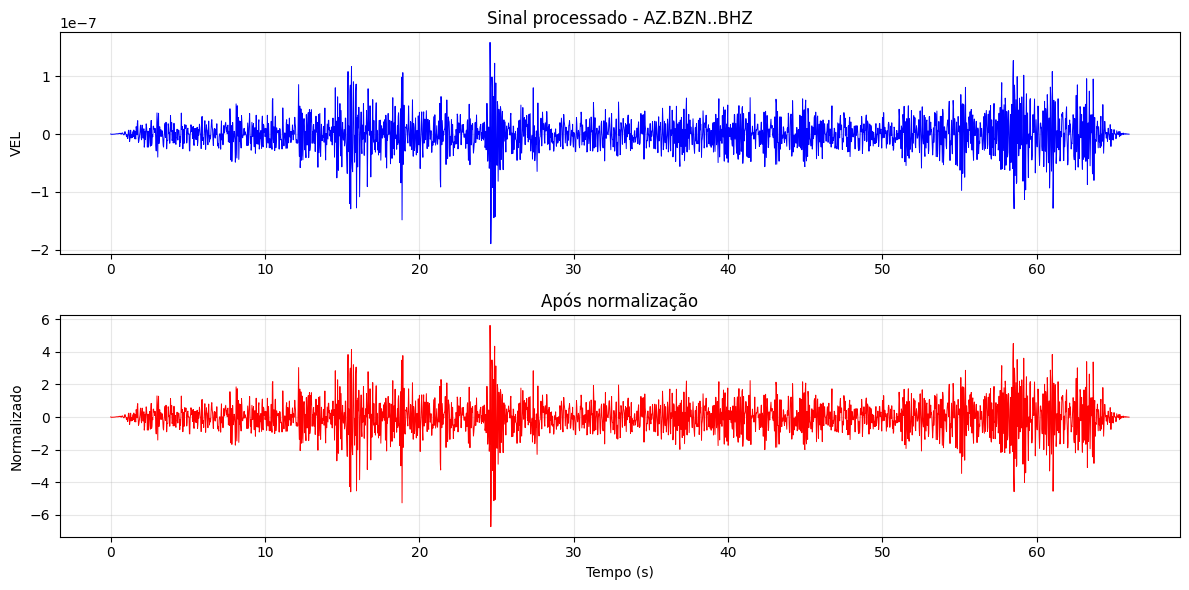

Metadados: {'network': 'AZ', 'station': 'BZN', 'channel': 'BHZ', 'sampling_rate': 40.0, 'starttime': UTCDateTime(2016, 1, 1, 0, 42, 3, 594500), 'npts': 2640}
Shape dos dados: (2640,)


In [18]:
#Testando pipeline
# Caminhos (ajuste conforme sua estrutura)
caminho_wave = r"C:\Users\vish8\OneDrive\Documentos\SeriesTemporaisSismicas\data\scedc-pds\event_waveforms\2016\2016_001\37509256.ms"
caminho_inv = r"C:\Users\vish8\OneDrive\Documentos\SeriesTemporaisSismicas\data\scedc-pds\FDSNstationXML\AZ\AZ.BZN.xml"

# Executar o pipeline
dados_proc, metadados = preprocessar_waveform(
    caminho_wave, caminho_inv, 
    canal_alvo='BHZ', output='VEL',
    pre_filt=(0.5, 1.0, 18.0, 20.0),
    normalizar=True, plot=True
)

print("Metadados:", metadados)
print("Shape dos dados:", dados_proc.shape)

Sinal normalizado:

Após normalização (z-score), a amplitude fica centrada em zero com desvio padrão 1.

Isso é essencial para o treinamento do autoencoder, pois garante que todas as janelas tenham a mesma escala.